In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [3]:
# 1
df = pd.read_csv('fcc-forum-pageviews.csv', parse_dates = True, index_col = 'date')
df

,value
date,
2016-05-09,1201
2016-05-10,2329
2016-05-11,1716
2016-05-12,10539
2016-05-13,6933
...,...
2019-11-29,171584
2019-11-30,141161
2019-12-01,142918


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1304 entries, 2016-05-09 to 2019-12-03
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   value   1304 non-null   int64
dtypes: int64(1)
memory usage: 20.4 KB


In [7]:
# 2
df = df[
    (df['value'] > df['value'].quantile(0.025)) &
    (df['value'] < df['value'].quantile(0.975))
]

df

,value
date,
2016-05-19,19736
2016-05-26,18060
2016-05-27,19997
2016-05-28,19044
2016-05-29,20325
...,...
2019-11-24,138875
2019-11-29,171584
2019-11-30,141161


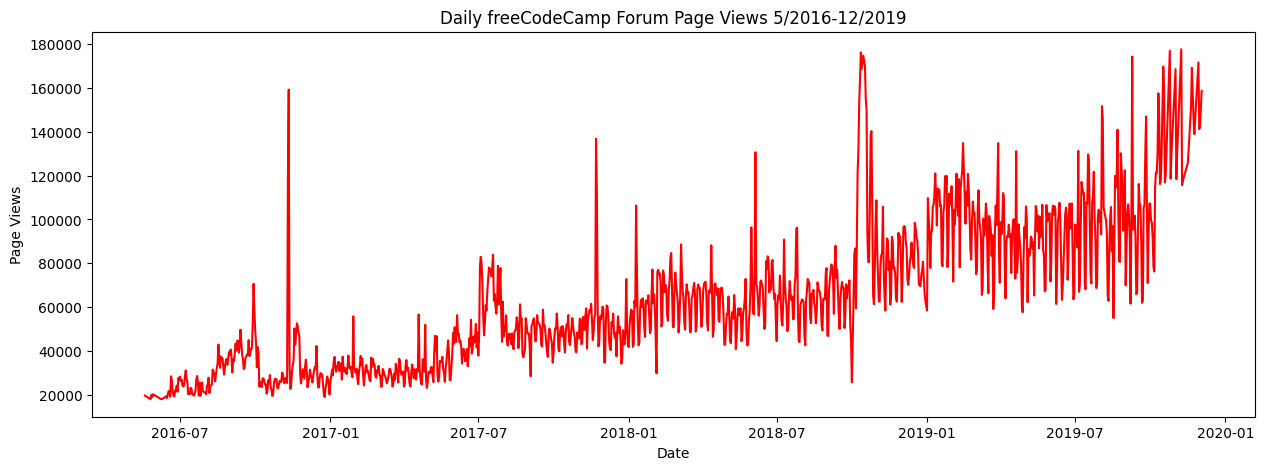

In [28]:
# 3
fig, ax = plt.subplots(figsize = (15,5))

ax.plot(df, color = 'r')
ax.set_ylabel('Page Views')
ax.set_xlabel('Date')
ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
plt.show()

In [67]:
df.groupby([df.index.year,df.index.month]).agg({'value':'mean'})

value
date date               
2016 5      19432.400000
     6      21875.105263
     7      24109.678571
     8      31049.193548
     9      41476.866667
     10     27398.322581
     11     40448.633333
     12     27832.419355
2017 1      32785.161290
     2      31113.071429
     3      29369.096774
     4      30878.733333
     5      34244.290323
     6      43577.500000
     7      65806.838710
     8      47712.451613
     9      47376.800000
     10     47438.709677
     11     57701.566667
     12     48420.580645
2018 1      58580.096774
     2      65679.000000
     3      62693.774194
     4      62350.833333
     5      56562.870968
     6      70117.000000
     7      63591.064516
     8      62831.612903
     9      65941.733333
     10    111378.142857
     11     78688.333333
     12     80047.483871
2019 1     102056.516129
     2     105968.357143
     3      91214.483871
     4      89368.433333
     5      91439.903226
     6      90435.642857
     7      97236.566667
     8     102717.310345
     9      97268.833333
     10    122802.272727
     11    143166.428571
     12    150733.500000

In [54]:
df.index.year

Index([2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016,
       ...
       2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019, 2019],
      dtype='int32', name='date', length=1238)

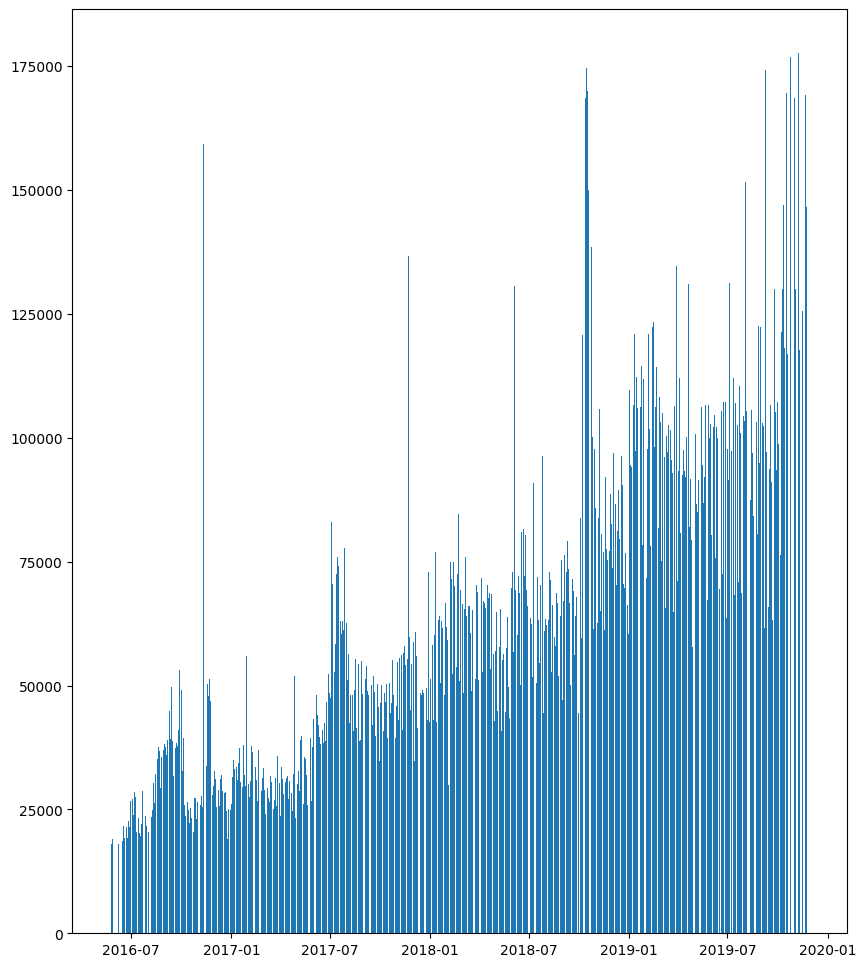

In [61]:
# 4
fig, ax = plt.subplots(figsize = (10,12))

ax.bar(x = df.index, height = 'value', data = df)
plt.show()